# 初始参数配置

In [83]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260411_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='ic',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.75,
    gp_crossover_prob=0.7,
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=5,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

KeyboardInterrupt: 

In [16]:
import random
rng = random.Random(None)
rng.random()

0.20076583099745104

# 提高随机性参数配置

In [84]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260413_gp_test_1',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=60,
    fitness_metric='ic',
    gp_max_depth=6,
    gp_population_size=500,  # 每轮生成的因子数量
    gp_elite_size=50,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.65,
    gp_crossover_prob=0.3,
    gp_leaf_prob=0.2,
    gp_const_prob=0.02,
    gp_mutation_prob=0.7,
    gp_tournament_size=3,
    gp_window_choices=[3, 5, 10, 20, 30],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=6,
    gp_depth_penalty_linear_coef=0.03,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=4,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:685: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return _group_apply_series(df, self.child.calc(df), lambda x: x.pct_change(self.window))
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:685: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return _group_apply_series(df, self.child.calc(df), lambda x: x.pct_change(self.window))
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:685: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-le

config_path: factors.genetic_programming@20260413_gp_test_1
selected_count: 5
selected_fc_name_list: ['fac_gp_0004', 'fac_gp_0006', 'fac_gp_0013', 'fac_gp_0024', 'fac_gp_0038']

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,5.158731e-17,2.241208e-17,9.344264e-17,9.347643e-17,0.552075,0.239762,0.697082,0.301846,0.000000e+00,0.000000e+00,...,"0(0.15486,0.122289)","0.552075(0.267796,-0.267796)","0.239762(0.267796,-0.267796)","0.504132(0.516529,0.466942)","0.487603(0.516529,0.466942)","5.78874e-16(0,0)",fac_gp_0049,1d,0.0002,C0
2023,2.741154e-16,2.262418e-16,1.813809e-16,1.782135e-16,1.511270,1.269498,2.037038,1.745119,1.110223e-16,1.110223e-16,...,"1.11022e-16(0.146334,0.115003)","1.51127(-1.08921,1.08921)","1.2695(-1.08921,1.08921)","0.528926(0.483471,0.491736)","0.5(0.483471,0.491736)","9.49873e-16(0,0)",fac_gp_0049,1d,0.0002,C0
2024,-2.472011e-16,-2.818727e-16,2.622711e-16,2.644034e-16,-0.942540,-1.066070,-0.694500,-0.831252,3.330669e-16,3.330669e-16,...,"3.33067e-16(0.176943,0.0575955)","-0.94254(-1.37663,1.37663)","-1.06607(-1.37663,1.37663)","0.454545(0.417355,0.541322)","0.438017(0.417355,0.541322)","6.87928e-16(0,0)",fac_gp_0049,1d,0.0002,C0
all,1.252538e-16,8.431547e-17,1.761756e-16,1.758464e-16,0.710960,0.479484,0.656351,0.454956,4.440892e-16,4.440892e-16,...,"4.44089e-16(0.30725,0.362493)","0.71096(0.176769,-0.176769)","0.479484(0.176421,-0.177116)","0.500825(0.495875,0.480198)","0.481848(0.495875,0.480198)","8.12269e-16(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,1.737227e-01,1.469368e-01,1.116681e-01,1.117277e-01,1.555706,1.315133,2.207031,1.898584,7.545640e-02,8.051460e-02,...,"0.0805146(0.0487138,0.291679)","1.55571(2.75956,-2.75956)","1.31513(2.75777,-2.76134)","0.436214(0.563786,0.411523)","0.427984(0.563786,0.411523)","0.531467(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,9.584809e-04,-3.948280e-02,1.722176e-01,1.722548e-01,0.005566,-0.229212,0.005157,-0.219280,1.549688e-01,1.680349e-01,...,"0.168035(0.148106,0.111244)","0.00556552(0.0391665,-0.0391665)","-0.229212(0.0391665,-0.0391665)","0.506173(0.497942,0.489712)","0.481481(0.497942,0.489712)","0.802406(0,0)",fac_gp_0050,1d,0.0002,C0
2022,1.019916e-01,7.755919e-02,8.990508e-02,9.013001e-02,1.134436,0.860526,1.571514,1.203028,8.978970e-02,9.412347e-02,...,"0.0941235(0.15486,0.122289)","1.13444(0.267796,-0.267796)","0.860526(0.267796,-0.267796)","0.5(0.516529,0.466942)","0.475207(0.516529,0.466942)","0.48477(0,0)",fac_gp_0050,1d,0.0002,C0
2023,3.905630e-01,3.517012e-01,1.525381e-01,1.511932e-01,2.560428,2.326171,3.712748,3.541973,5.404414e-02,5.587324e-02,...,"0.0558732(0.146334,0.115003)","2.56043(-1.08921,1.08921)","2.32617(-1.08921,1.08921)","0.570248(0.483471,0.491736)","0.549587(0.483471,0.491736)","0.771068(0,0)",fac_gp_0050,1d,0.0002,C0
2024,1.321902e-01,9.984519e-02,1.422201e-01,1.417690e-01,0.929476,0.704281,1.185711,0.945880,6.091750e-02,6.295173e-02,...,"0.0629517(0.176943,0.0575955)","0.929476(-1.37663,1.37663)","0.704281(-1.37663,1.37663)","0.454545(0.417355,0.541322)","0.442149(0.417355,0.541322)","0.641766(0,0)",fac_gp_0050,1d,0.0002,C0


In [74]:
    # 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
2


In [75]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0018     True
fac_gp_0001    False
fac_gp_0039    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0038    False
fac_gp_0040    False
fac_gp_0028    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0029    False
fac_gp_0026    False
fac_gp_0027    False
fac_gp_0014    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0015    False
fac_gp_0002    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
fac_gp_0022    False
fac_gp_0023    False
f

In [76]:
print(check2)

Factor Name
fac_gp_0039     True
fac_gp_0024     True
fac_gp_0006     True
fac_gp_0023     True
fac_gp_0018     True
fac_gp_0038    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0001    False
fac_gp_0028    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0029    False
fac_gp_0026    False
fac_gp_0027    False
fac_gp_0002    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [77]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0036    1.437024
fac_gp_0002    1.305248
fac_gp_0043    1.277004
fac_gp_0016    1.257260
fac_gp_0007    1.091185
fac_gp_0021    1.051736
fac_gp_0006    1.044463
fac_gp_0003    1.016775
fac_gp_0005    1.006019
fac_gp_0011    0.977656
fac_gp_0031    0.976815
fac_gp_0013    0.951622
fac_gp_0025    0.940876
fac_gp_0020    0.937951
fac_gp_0045    0.934750
fac_gp_0023    0.921054
fac_gp_0033    0.892492
fac_gp_0018    0.886585
fac_gp_0024    0.883043
fac_gp_0030    0.855232
fac_gp_0049    0.845313
fac_gp_0010    0.844178
fac_gp_0001    0.839073
fac_gp_0039    0.815084
fac_gp_0040    0.811663
fac_gp_0037    0.799902
fac_gp_0047    0.760220
fac_gp_0048    0.754360
fac_gp_0017    0.732506
fac_gp_0028    0.676995
fac_gp_0046    0.655936
fac_gp_0027    0.651786
fac_gp_0035    0.620248
fac_gp_0008    0.596058
fac_gp_0041    0.582817
fac_gp_0015    0.572103
fac_gp_0034    0.568827
fac_gp_0032    0.556931
fac_gp_0029    0.537195
fac_gp_0038    0.496179
fac_gp_0050    0.477588
fac_

In [78]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0043    0.188511
fac_gp_0016    0.175411
fac_gp_0007    0.163625
fac_gp_0033    0.160608
fac_gp_0023    0.152515
fac_gp_0013    0.146133
fac_gp_0002    0.143579
fac_gp_0045    0.132782
fac_gp_0011    0.132121
fac_gp_0006    0.128224
fac_gp_0021    0.126026
fac_gp_0040    0.123791
fac_gp_0030    0.118439
fac_gp_0020    0.117296
fac_gp_0049    0.114959
fac_gp_0025    0.114337
fac_gp_0024    0.107298
fac_gp_0017    0.102282
fac_gp_0039    0.099666
fac_gp_0037    0.099264
fac_gp_0031    0.096714
fac_gp_0048    0.091671
fac_gp_0018    0.090667
fac_gp_0010    0.083854
fac_gp_0015    0.080955
fac_gp_0008    0.076921
fac_gp_0027    0.076750
fac_gp_0003    0.076122
fac_gp_0047    0.075896
fac_gp_0034    0.074871
fac_gp_0041    0.071583
fac_gp_0032    0.071036
fac_gp_0001    0.068033
fac_gp_0029    0.060284
fac_gp_0005    0.057041
fac_gp_0004    0.055521
fac_gp_0038    0.055416
fac_gp_0012    0.055330
fac_gp_0050    0.054063
fac_gp_0022    0.052089
fac_gp_0035    0.050185
fac_

In [79]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0002    0.095800
fac_gp_0011    0.091198
fac_gp_0016    0.089749
fac_gp_0043    0.088851
fac_gp_0036    0.086072
fac_gp_0001    0.082533
fac_gp_0007    0.079783
fac_gp_0010    0.077656
fac_gp_0006    0.077410
fac_gp_0048    0.075536
fac_gp_0027    0.074782
fac_gp_0021    0.074295
fac_gp_0003    0.074088
fac_gp_0045    0.074081
fac_gp_0005    0.072955
fac_gp_0023    0.071816
fac_gp_0033    0.069586
fac_gp_0013    0.069227
fac_gp_0049    0.068949
fac_gp_0039    0.068229
fac_gp_0018    0.068208
fac_gp_0041    0.066989
fac_gp_0024    0.066268
fac_gp_0046    0.065098
fac_gp_0017    0.064723
fac_gp_0008    0.064014
fac_gp_0040    0.063861
fac_gp_0020    0.063577
fac_gp_0032    0.061151
fac_gp_0037    0.060775
fac_gp_0030    0.060510
fac_gp_0031    0.060444
fac_gp_0025    0.060382
fac_gp_0047    0.060278
fac_gp_0012    0.060005
fac_gp_0038    0.059663
fac_gp_0034    0.059542
fac_gp_0004    0.056424
fac_gp_0042    0.052737
fac_gp_0028    0.052714
fac_gp_0035    0.051172
fac_

In [80]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 Neg(Delta(Div(Abs(PriceAcceleration(open, 3)), TsArgmax(Add(close, TsMax(high, 20)), 10))))
fac_gp_0002 TsArgmin(Div(position, TsRankCorr(Add(low, TsMax(high, 20)), high, 3)), 10)
fac_gp_0003 Neg(Delta(Div(Abs(Abs(PriceAcceleration(open, 3))), TsArgmax(Ema(open, 5), 10))))
fac_gp_0004 Neg(Delta(Div(Abs(PriceAcceleration(open, 3)), TsArgmax(Mul(TsArgmax(open, 5), close), 10))))
fac_gp_0005 TsArgmin(Div(position, TsRankCorr(low, Max(close, open), 3)), 10)
fac_gp_0006 Neg(TsArgmin(Div(position, TsRankCorr(Mul(TurnoverShock(position, 20), close), high, 3)), 10))
fac_gp_0007 Neg(TsDelay(TsTimeWeightedMean(TsRankCorr(low, TsMean(close, 30), 3), 20), 3))
fac_gp_0008 Mul(Delta(SqrtAbs(Add(Min(low, close), Delta(close)))), TsArgmax(close, 10))
fac_gp_0009 Delta(Div(OiTrendConviction(TsMean(TsDecayExp(open, 30), 20), position), TsArgmax(Add(close, TsMax(high, 20)), 10)))
fac_gp_0010 Neg(Delta(Div(Abs(PriceAcceleration(open, 3)), TsArgmax(Add(Delta(high), TsMax(open, 20)), 10))))
fac_

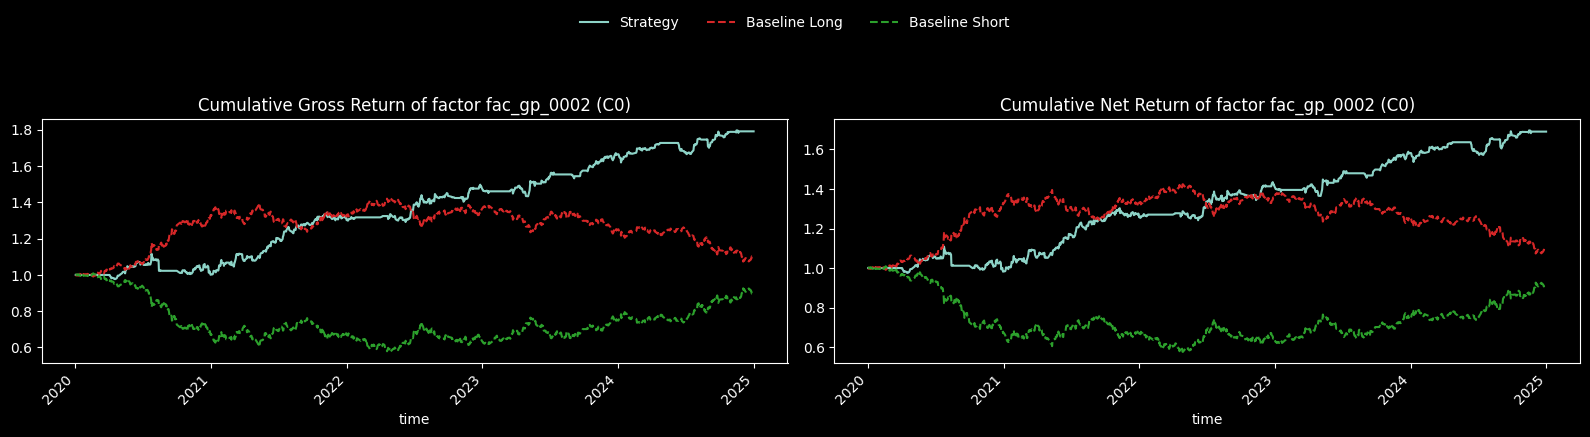

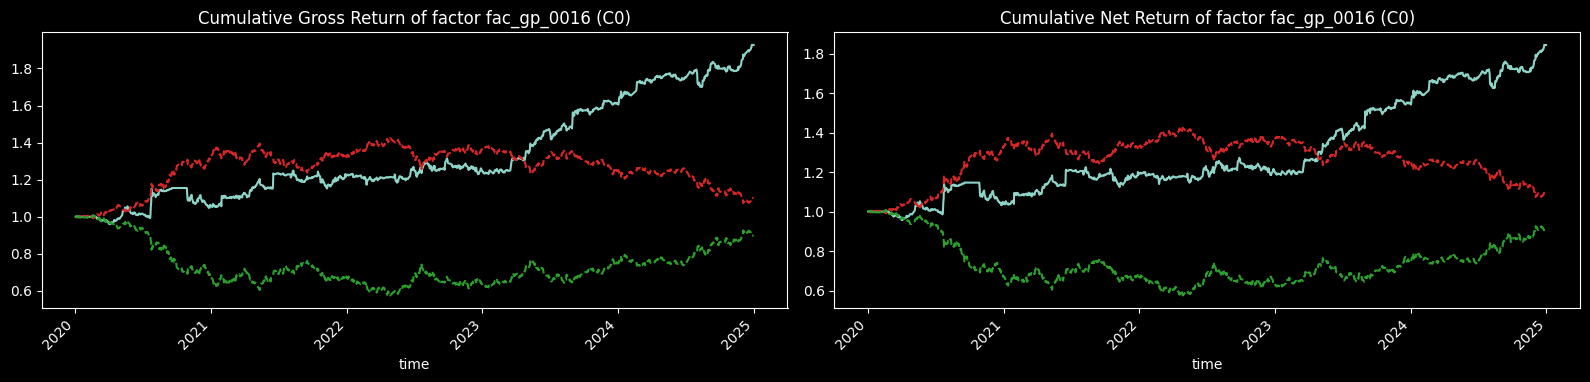

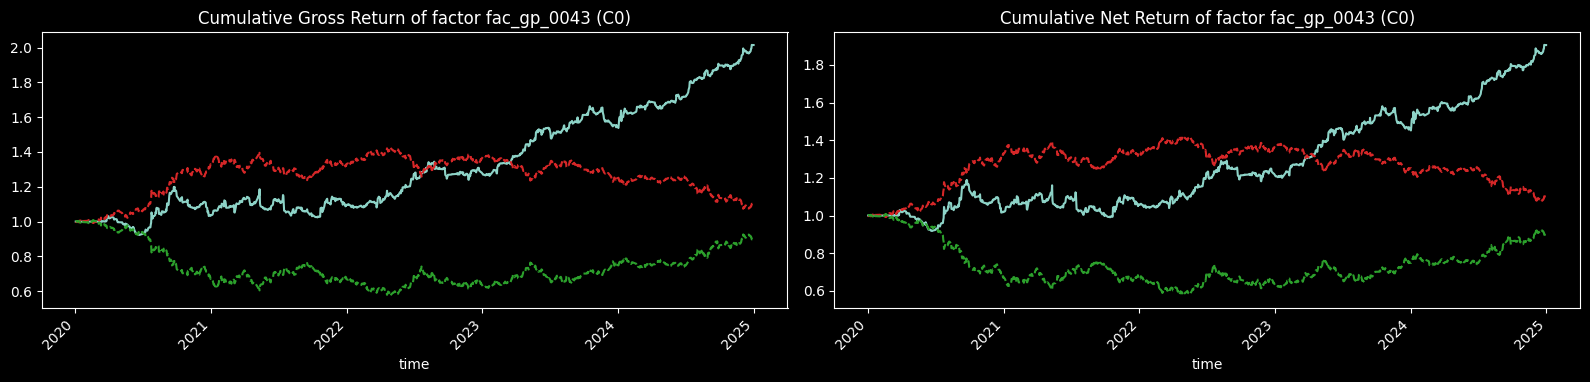

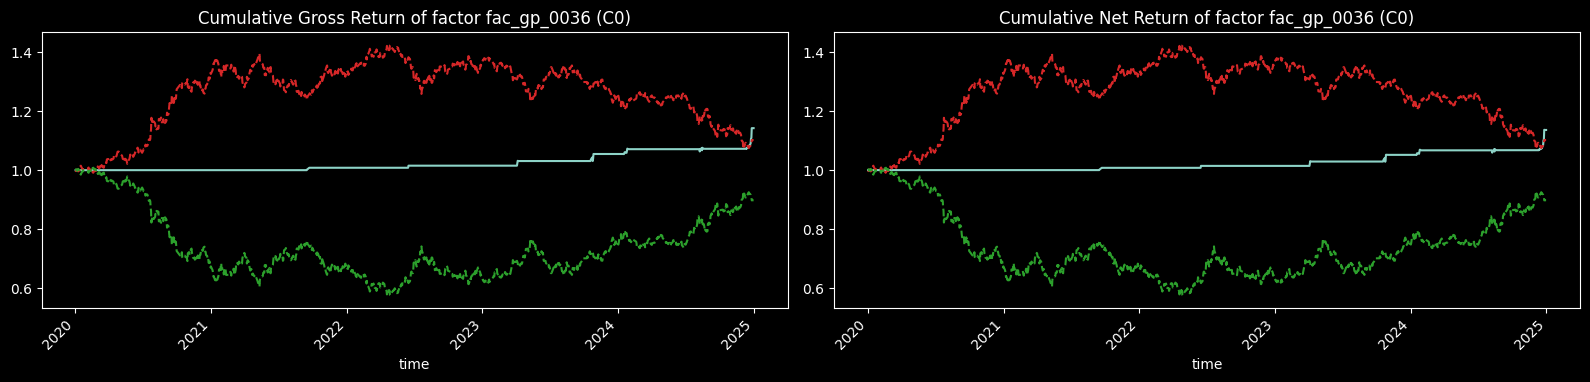

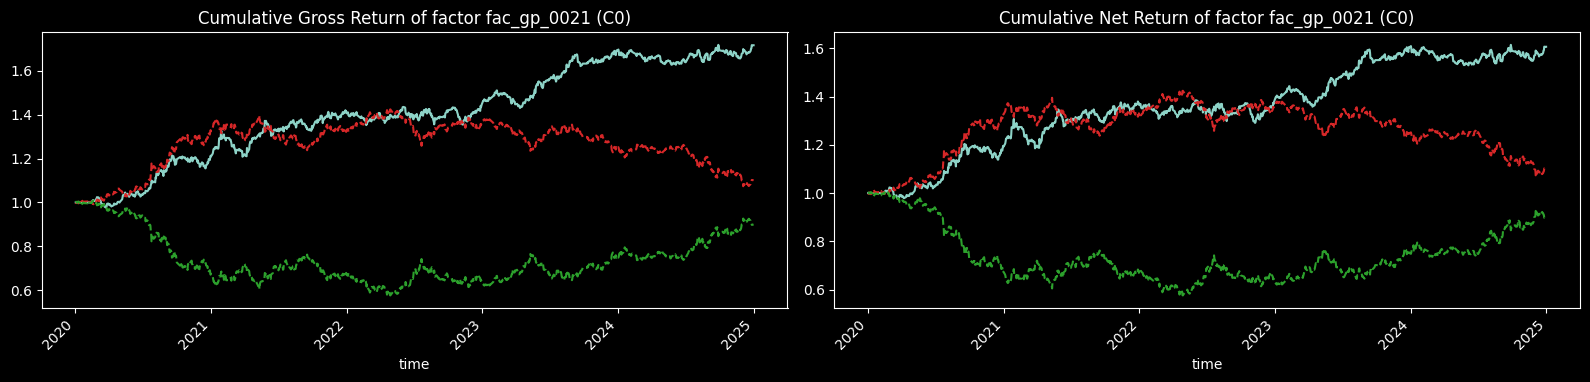

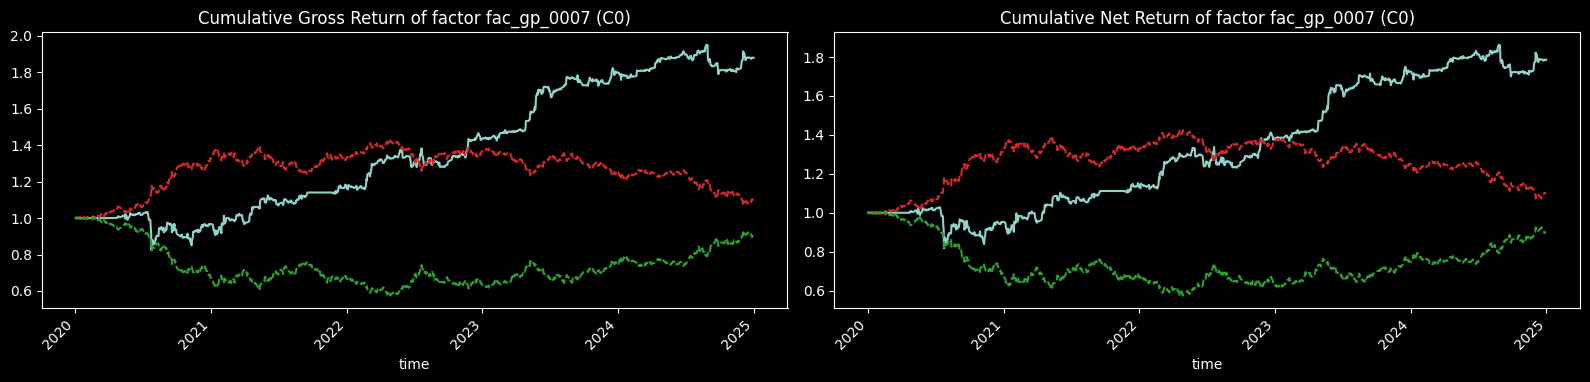

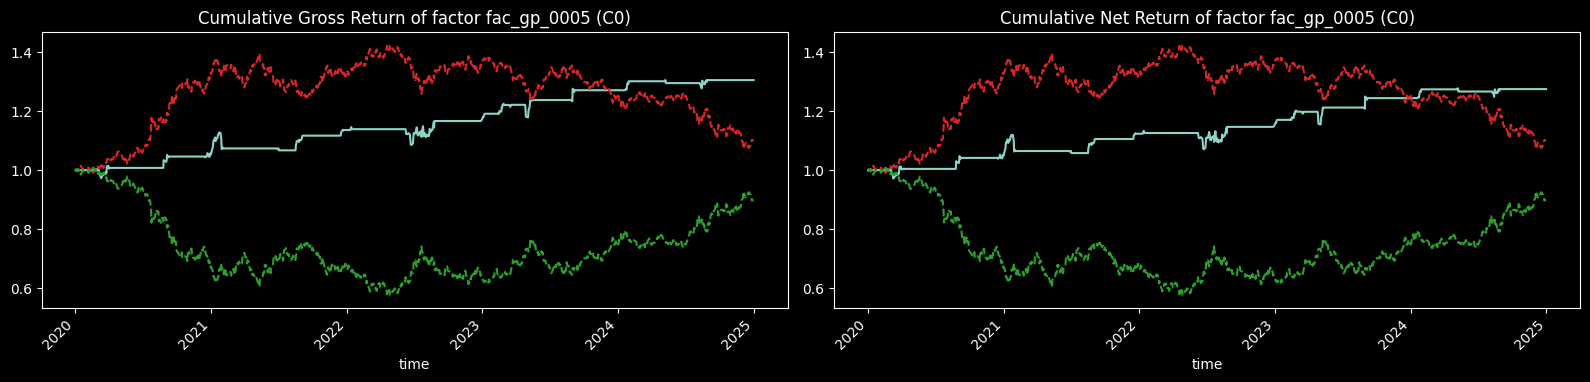

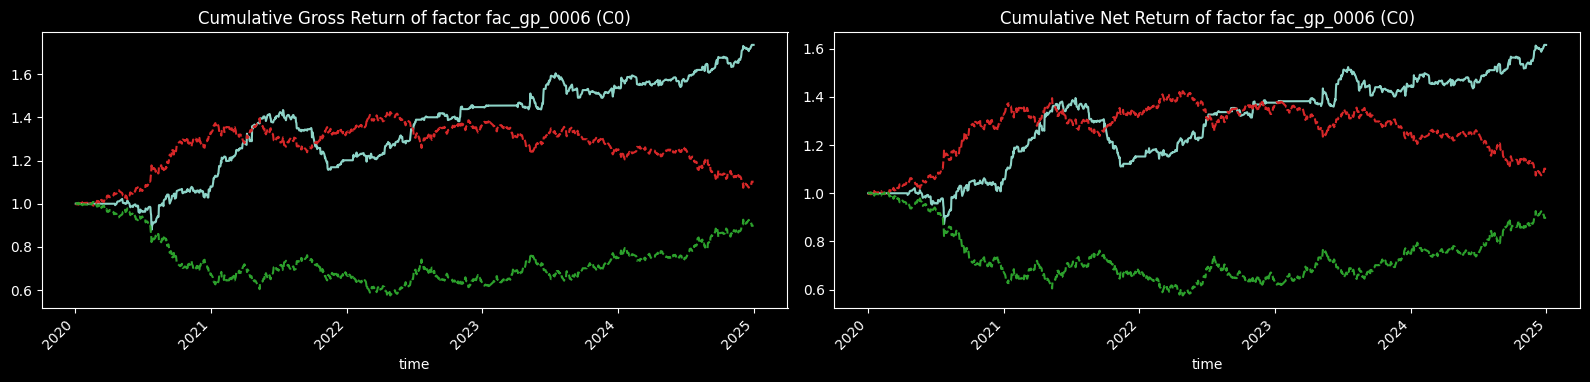

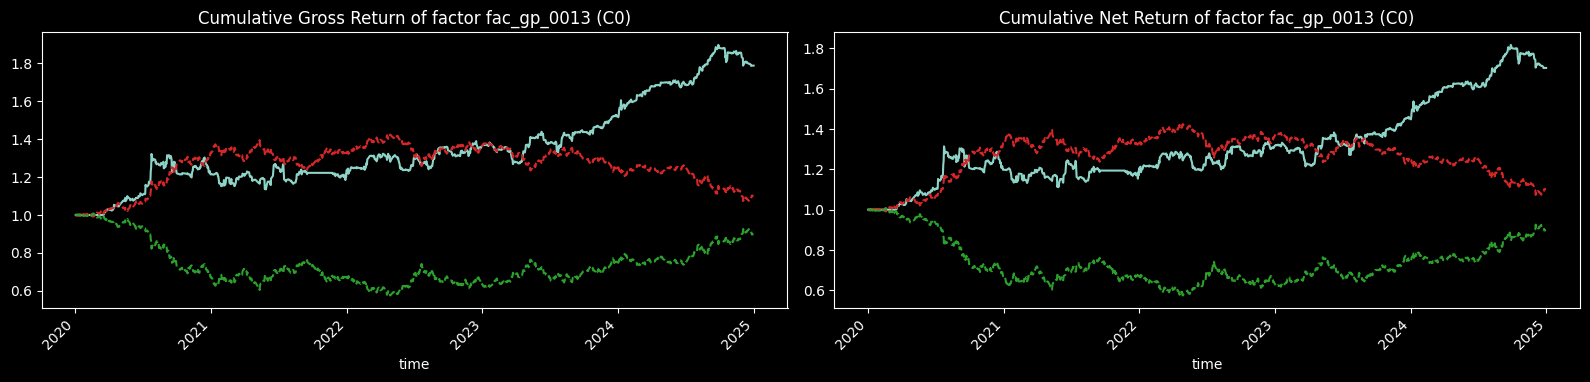

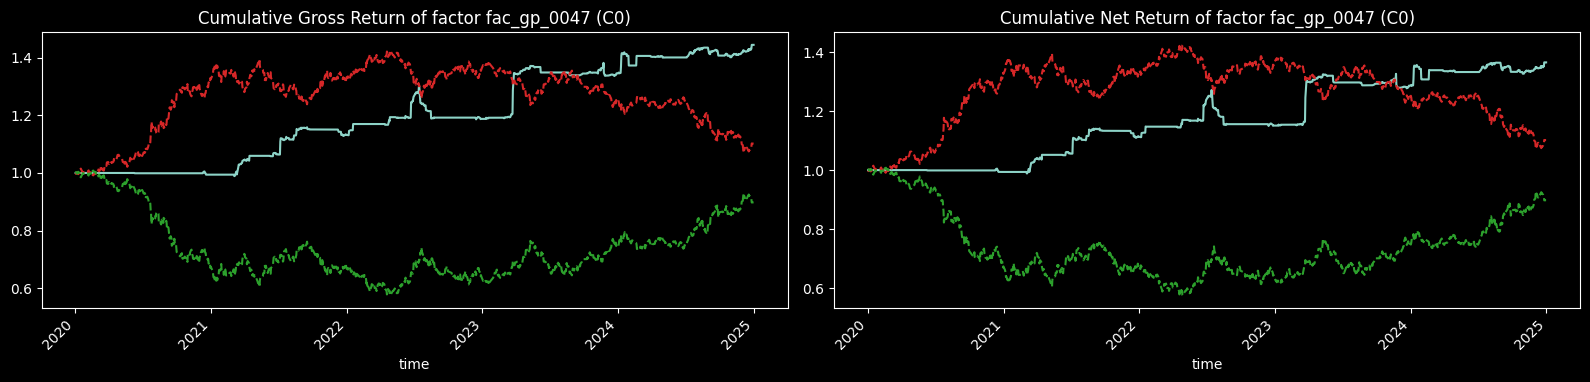

In [81]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

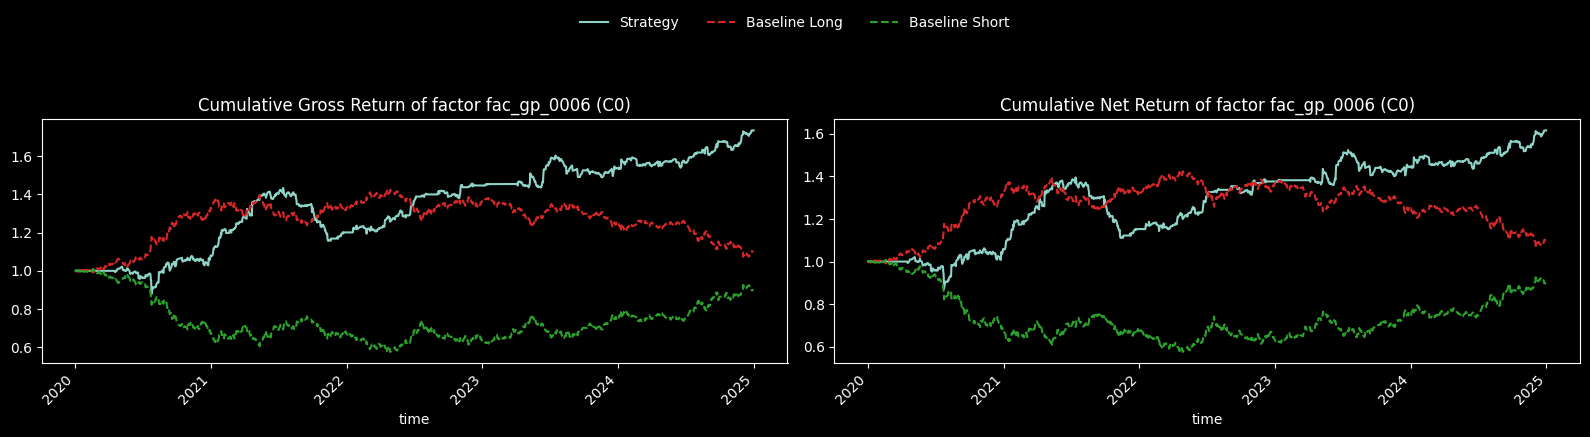

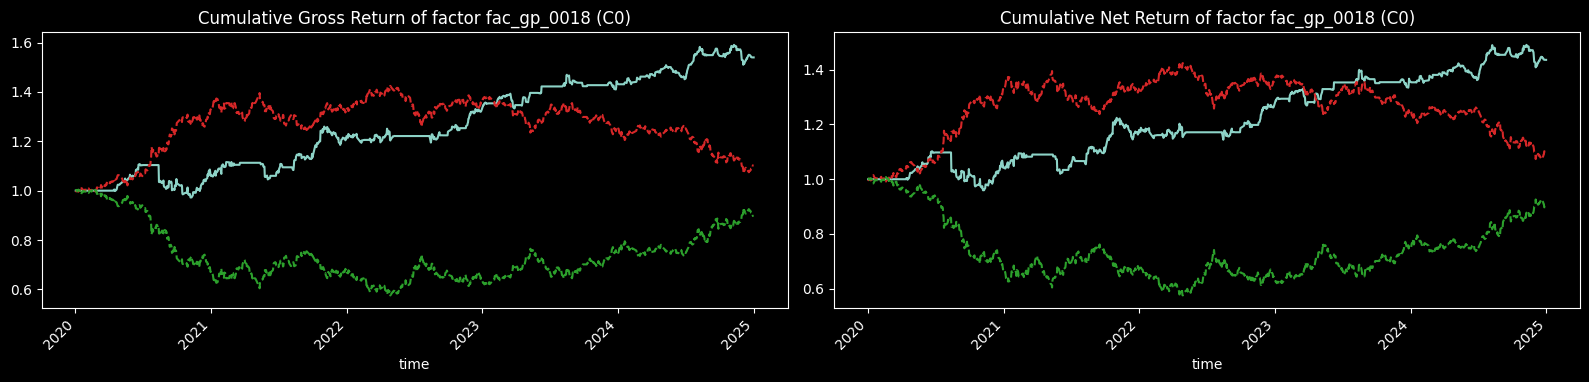

In [82]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=True)

In [ ]:
from datetime import datetime

In [ ]:
date_str = datetime.now().strftime('%Y%m%d')
date_str